                  Date    Product  Sales  Quantity Region
0  2023-01-01 00:00:00  Product A    200         4  North
1  2023-02-01 00:00:00  Product B    150         3  South
2  2023-03-01 00:00:00  Product A    220         5  North
3  2023-04-01 00:00:00  Product C    300         6   East
4  2023-05-01 00:00:00  Product B    180         4   West
Date        0
Product     0
Sales       0
Quantity    0
Region      0
dtype: int64
            Sales   Quantity
count   16.000000  16.000000
mean   237.500000   5.375000
std     64.031242   1.746425
min    150.000000   3.000000
25%    187.500000   4.000000
50%    225.000000   5.500000
75%    302.500000   7.000000
max    340.000000   8.000000
     Product  Sales  Quantity
0  Product A   1350        33
1  Product B    850        17
2  Product C   1600        36


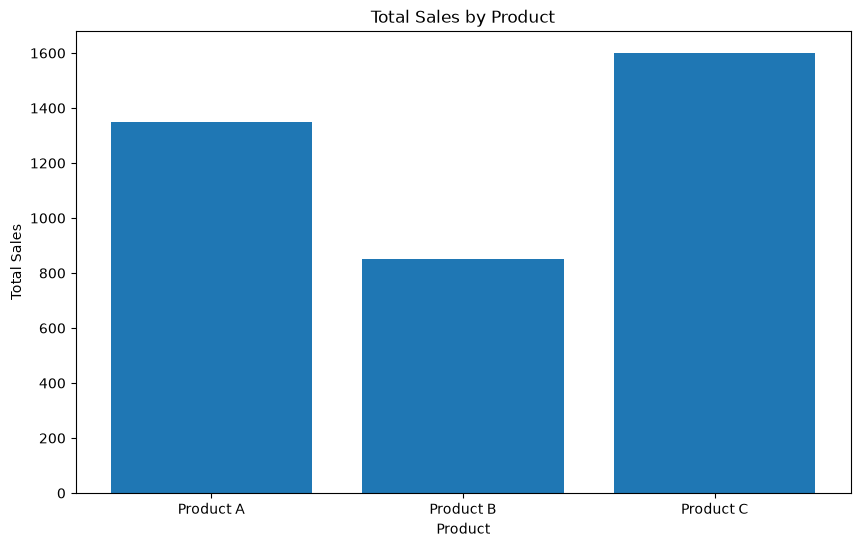

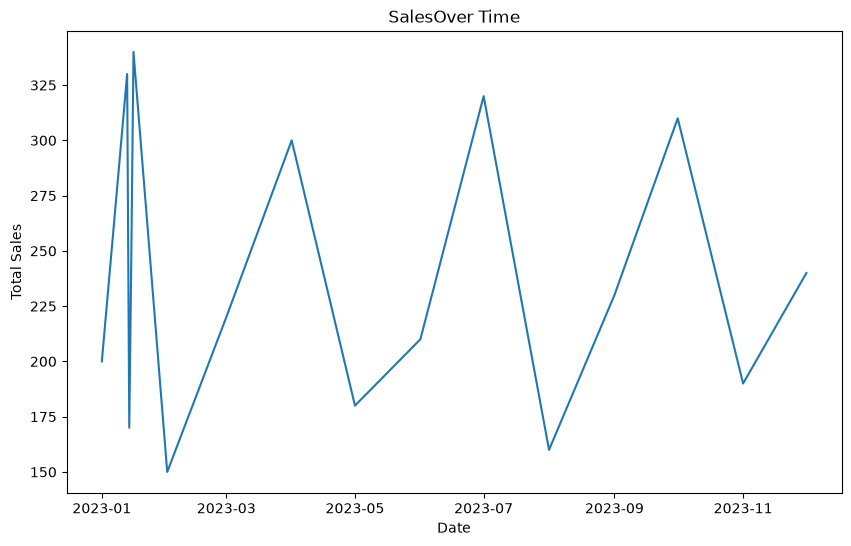

Product  Product A  Product B  Product C
Region                                  
East             0          0       1600
North         1350          0          0
South            0        480          0
West             0        370          0
             Sales  Quantity
Sales     1.000000  0.944922
Quantity  0.944922  1.000000


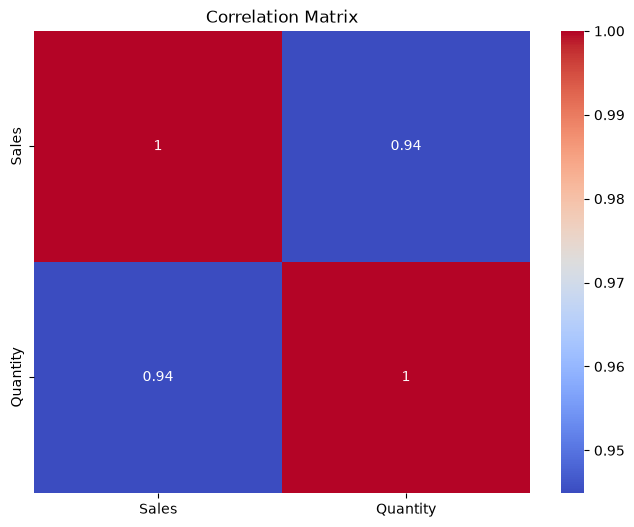

In [5]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

# Load the data into a pandas DataFrame

file_path='sales_data.xlsx'

df = pd.read_excel(file_path)

# Display the first few rows of the DataFrame

print(df.head())

# Check for missing values

print(df.isnull().sum())

# Fill or drop missing values if necessary

df['Sales'].fillna(df['Sales'].mean())

df.dropna(subset=['Product', 'Quantity', 'Region'], inplace=True)

# Summary statistics

print(df.describe())

# Group by product and calculate the total sales and quantity

product_summary = df.groupby('Product').agg({

'Sales': 'sum',

'Quantity': 'sum'

}).reset_index()

print(product_summary)

# Bar plot of total sales by product

plt.figure(figsize=(10, 6))

plt.bar(product_summary['Product'],

product_summary['Sales'])

plt.xlabel('Product')

plt.ylabel ('Total Sales')

plt.title('Total Sales by Product')

plt.show()

# Line plot of sales over time

df['Date'] = pd.to_datetime(df['Date'])

sales_over_time = df.groupby('Date').agg({'Sales':'sum'}).reset_index()

plt.figure(figsize=(10, 6))

plt.plot(sales_over_time['Date'],sales_over_time['Sales']) 

plt.xlabel('Date')

plt.ylabel('Total Sales')

plt.title('SalesOver Time')

plt.show()

# Pivot table to analyze sales by region and product

pivot_table = df.pivot_table(values='Sales', index='Region', columns='Product', aggfunc=np.sum, fill_value=0)

print(pivot_table)

# Correlation matrix

correlation_matrix = df.corr(numeric_only=True)

print(correlation_matrix)

#Heatmap of the correlation matrix

import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')

plt.show()